In [1]:
import matplotlib.pyplot as plt
from grism_sim_psf_dependent import mk_grism
from astropy.table import Table
import image_utils as iu
import os
import numpy as np

/Users/keith/miniconda3/envs/grizli1/lib/python3.12/site-packages/pysynphot/refs.py:117: UserWarning: No graph or component tables found; functionality will be SEVERELY crippled. No files found for /Users/keith/astr/research/env_data_dir/PYSYN_CDBS/mtab/*_tmg.fits
  warnings.warn('No graph or component tables found; '
/Users/keith/miniconda3/envs/grizli1/lib/python3.12/site-packages/pysynphot/refs.py:124: UserWarning: No thermal tables found, no thermal calculations can be performed. No files found for /Users/keith/astr/research/env_data_dir/PYSYN_CDBS/mtab/*_tmt.fits
  warnings.warn('No thermal tables found, '


In [2]:
wfi_ra = 10
wfi_dec = 0
wfi_pa = 60

wfi_siaf = iu.get_wfi_siaf(wfi_ra, wfi_dec, wfi_pa, det_num=(det_num:=1))

det_coords = [[2043, 2043],
              [100, 100],
              [100, 3900],
              [3900, 100],
              [3900, 3900]]

nstar = len(det_coords)

mag = [1 for _ in range(nstar)]
sed_temp = [154. for _ in range(nstar)]

ra = []
dec = []

for coord in det_coords:
    r, d = wfi_siaf.det_to_sky(*coord)
    ra.append(r)
    dec.append(d)

stars = Table(
    [ra, dec, mag, sed_temp],
    names=["RA", 'DEC', 'magnitude', 'star_template_index']
)

In [3]:
confdir = "/Users/keith/astr/research/grism_sim/data/testbuild"
conf = {
    "SCA01": "TestBuild_rot_det1.conf",
    "SCA02": "TestBuild_rot_det2.conf",
    "SCA03": "TestBuild_rot_det3.conf",
    "SCA04": "TestBuild_rot_det4.conf",
    "SCA05": "TestBuild_rot_det5.conf",
    "SCA06": "TestBuild_rot_det6.conf",
    "SCA07": "TestBuild_rot_det7.conf",
    "SCA08": "TestBuild_rot_det8.conf",
    "SCA09": "TestBuild_rot_det9.conf",
    "SCA010": "TestBuild_rot_det10.conf",
    "SCA011": "TestBuild_rot_det11.conf",
    "SCA012": "TestBuild_rot_det12.conf",
    "SCA013": "TestBuild_rot_det13.conf",
    "SCA014": "TestBuild_rot_det14.conf",
    "SCA015": "TestBuild_rot_det15.conf",
    "SCA016": "TestBuild_rot_det16.conf",
    "SCA017": "TestBuild_rot_det17.conf",
    "SCA018": "TestBuild_rot_det18.conf",
}

In [4]:
res = mk_grism(wfi_cen_ra=10, wfi_cen_dec=0, wfi_cen_pa=60, det_num=det_num,
               star_input=stars, gal_input=None,
               output_dir=os.getenv("SCRATCH"),
               confdir=confdir, conf=conf)

checkpoint_0
checkpoint_1


 [astropy.io.fits.verify]


checkpoint_2
checkpoint_3
checkpoint_4




Image cutout: x=slice(0, 6088, None), y=slice(0, 6088, None) [Out of range]
/Users/keith/astr/research/SCRATCH/empty_grism_ra10_dec0_pa60_detSCA01.fits / blot reference /Users/keith/astr/research/SCRATCH/refimage_ra10_dec0_pa60_detSCA01_nopad.fits[0]
The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    
The following tasks in the drizzlepac package can be run with TEAL:
    astrodrizzle       config_testbed      imagefindpars           mapreg       
       photeq            pixreplace           pixtopix            pixtosky      
  refimagefindpars       resetbits          runastrodriz          skytopix      
     tweakback            tweakreg           updatenpol
Using default C-based coordinate transformation...
checkpoint_5
starting at 10000.0
adding stars to model
starting at 10500.0
adding stars to model
starting at 11000.0
adding stars to model
starting at 11500.0
adding stars to model


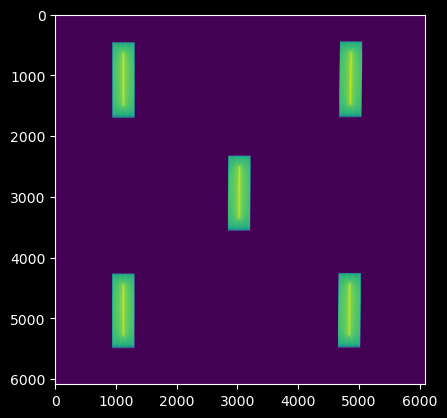

In [5]:
plt.imshow(np.log(res+1e-10))